In [ ]:
import kagglehub
gti_upm_leapgestrecog_path = kagglehub.dataset_download('gti-upm/leapgestrecog')

print('Data source import complete.')

Using Colab cache for faster access to the 'leapgestrecog' dataset.
Data source import complete.


## Imports

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
from glob import glob
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from concurrent.futures import ThreadPoolExecutor
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import matplotlib.patches as mpatches

## Data Loading & Preprocessing

### Dataset Loading

In [ ]:
DATA_DIR = os.path.join(gti_upm_leapgestrecog_path, 'leapGestRecog')

image_paths = []
labels = []

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        if filename.endswith('.png'):
            full_path = os.path.join(dirname, filename)
            image_paths.append(full_path)
            label = os.path.basename(dirname)
            labels.append(label)

print(f"Total images found: {len(image_paths)}")
print(f"Unique classes: {sorted(set(labels))}")

df = pd.DataFrame({'path': image_paths, 'label': labels})
print(df['label'].value_counts())

Total images found: 20000
Unique classes: ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']
label
02_l             2000
04_fist_moved    2000
09_c             2000
10_down          2000
06_index         2000
08_palm_moved    2000
07_ok            2000
05_thumb         2000
01_palm          2000
03_fist          2000
Name: count, dtype: int64


### Image Enhancment

In [ ]:
IMG_SIZE = (128, 128)

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Padding
    h, w = img.shape
    scale = min(IMG_SIZE[0] / h, IMG_SIZE[1] / w)
    new_h, new_w = int(h * scale), int(w * scale)
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Pad to exact square with black (zeros)
    pad_top    = (IMG_SIZE[0] - new_h) // 2
    pad_bottom = IMG_SIZE[0] - new_h - pad_top
    pad_left   = (IMG_SIZE[1] - new_w) // 2
    pad_right  = IMG_SIZE[1] - new_w - pad_left
    img = cv2.copyMakeBorder(img, pad_top, pad_bottom, pad_left, pad_right,
                              cv2.BORDER_CONSTANT, value=0)


    # Noise removal
    img = cv2.fastNlMeansDenoising(img, h=10)

    # CLAHE histogram enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Normalize
    img = img.astype(np.float32) / 255.0

    return img

### Preprocessing Visualization

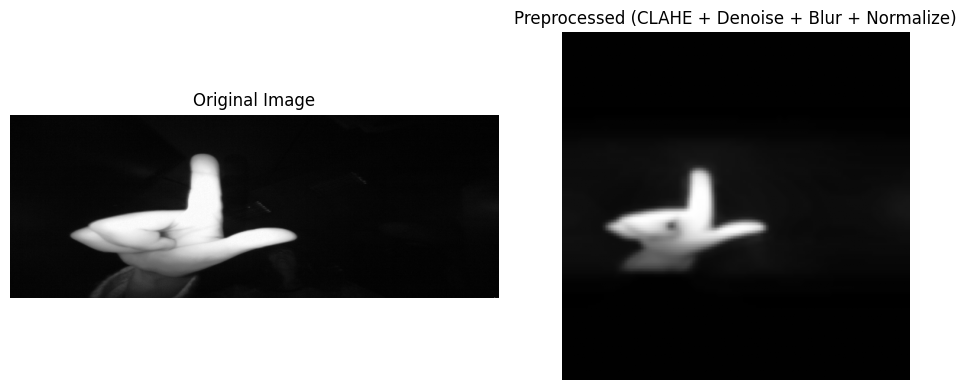

In [ ]:
sample_path = df['path'].iloc[0]
raw = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
processed = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(raw, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(processed, cmap='gray')
axes[1].set_title('Preprocessed (CLAHE + Denoise + Blur + Normalize)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Segmentation

### Segmentation Pipeline

In [ ]:
# Otsu thresholding, Morphological cleanup (Closing + Opening)
def segment_hand(preprocessed_img):
    img = (preprocessed_img * 255).astype(np.uint8)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask,   cv2.MORPH_OPEN,  kernel)
    return binary, mask, preprocessed_img * (mask / 255.0)

### Segmentation Visualization

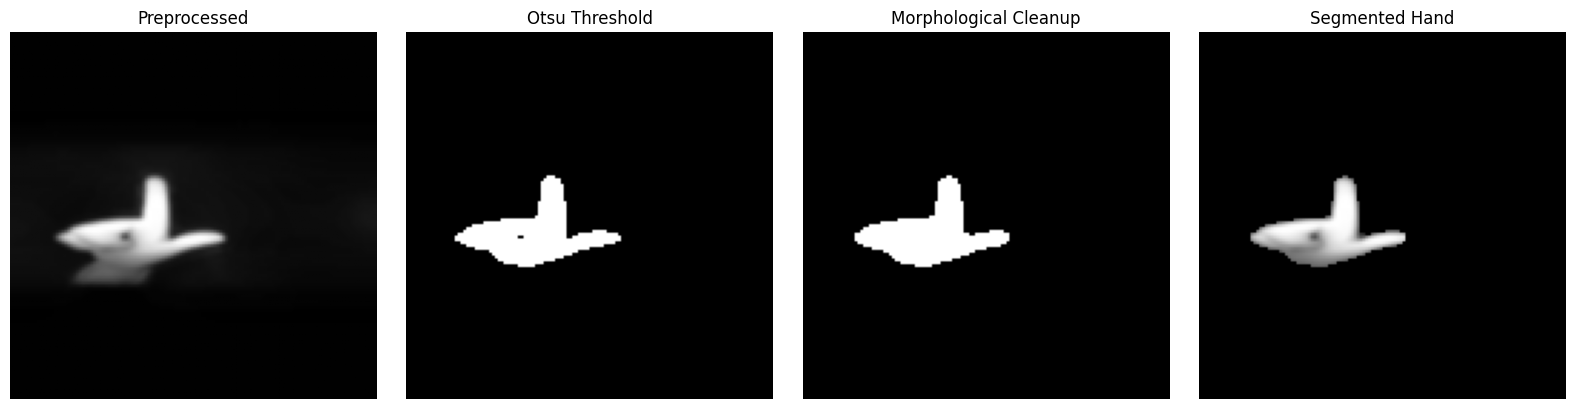

In [ ]:
# Visualize each segmentation step
binary, mask, segmented = segment_hand(processed)

titles = ['Preprocessed', 'Otsu Threshold','Morphological Cleanup', 'Segmented Hand']
images = [processed, binary, mask, segmented]

plt.figure(figsize=(16, 4))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Segmentation Results

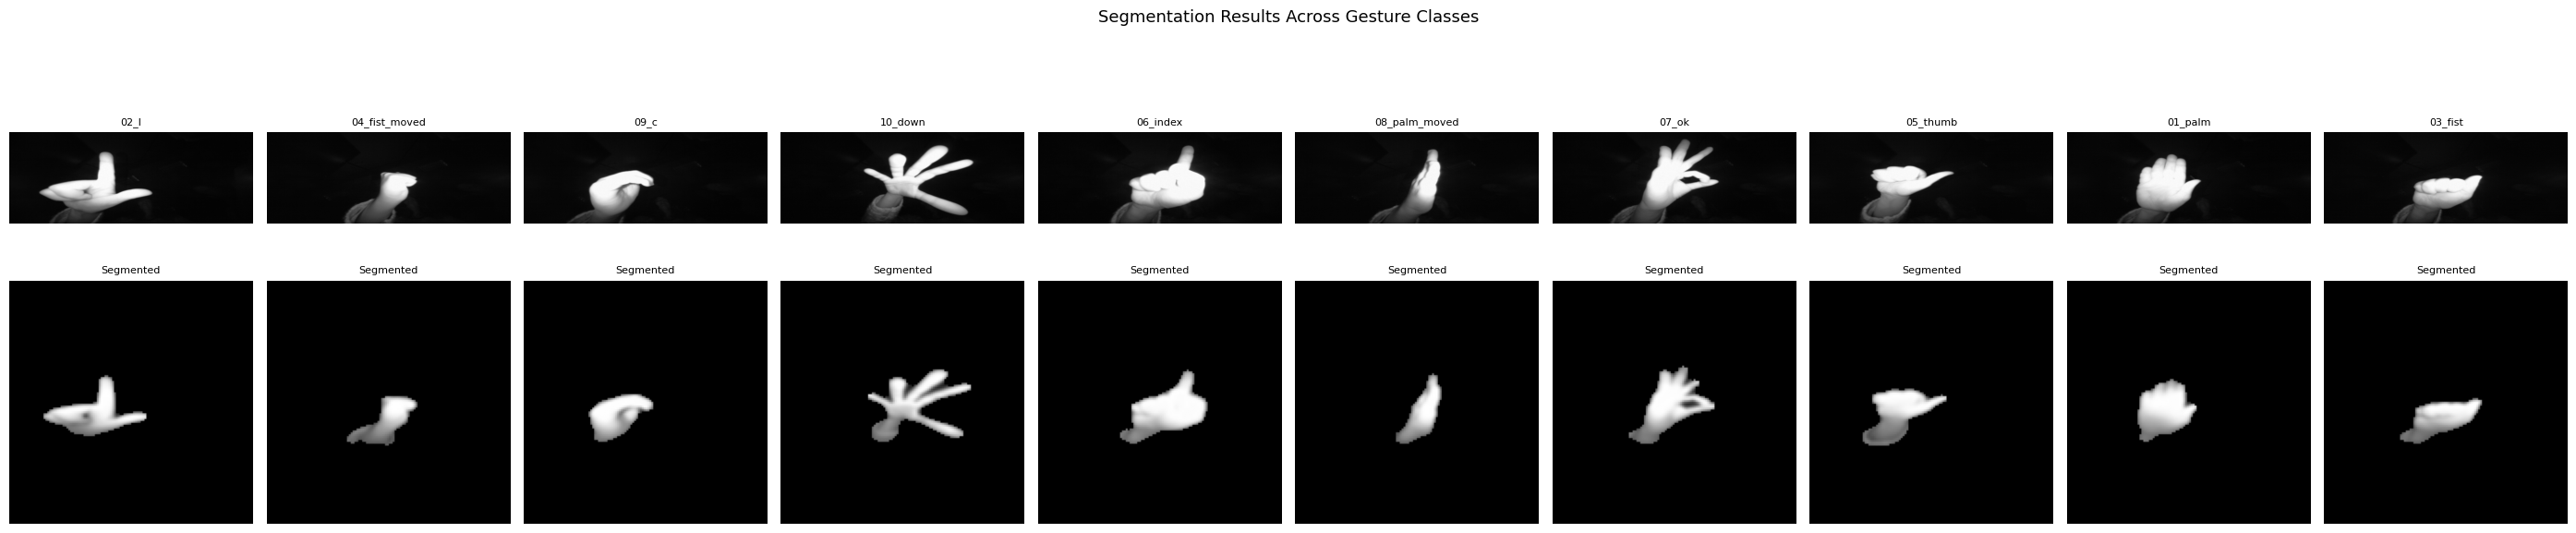

In [ ]:
# Test segmentation on one sample from each gesture class
classes = df['label'].unique()
plt.figure(figsize=(28, 6))

for i in range(len(classes)):
    cls = classes[i]
    path = df[df['label'] == cls]['path'].iloc[0]

    raw_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    processed = preprocess_image(path)
    binary, mask, seg_img = segment_hand(processed)

    plt.subplot(2, 10, i + 1)
    plt.imshow(raw_img, cmap='gray')
    plt.title(cls, fontsize=8)
    plt.axis('off')

    plt.subplot(2, 10, i + 11)
    plt.imshow(seg_img, cmap='gray')
    plt.title('Segmented', fontsize=8)
    plt.axis('off')

plt.suptitle('Segmentation Results Across Gesture Classes', fontsize=13)

plt.tight_layout()
plt.show()

## Feature Extraction

In [ ]:
def process_image(row):

    path = row['path']
    label = row['label']

    # Read + preprocess
    img = preprocess_image(path)

    if img is None:
        return None

    # Segmentation
    _, _, segmented = segment_hand(img)

    segmented = (segmented * 255).astype(np.uint8)

    # Smaller size = faster
    segmented = cv2.resize(segmented, (48, 48))

    # HOG features
    features = hog(
        segmented,
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    return features, label


# Multi-threading
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_image,[row for _, row in df.iterrows()]))

# Remove failed images
results = [r for r in results if r is not None]

# Split features and labels
X_raw = np.array([r[0] for r in results], dtype=np.float32)
y_raw = np.array([r[1] for r in results])

print("Feature Matrix Shape:", X_raw.shape)
print("Labels Shape:", y_raw.shape)

Feature Matrix Shape: (20000, 800)
Labels Shape: (20000,)


### Feature Scaling

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_raw)

print("Scaled Features Shape:", X_scaled.shape)

Scaled Features Shape: (20000, 800)


## PCA

### Determine Number of Components

In [ ]:
pca = PCA().fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Components for 95% variance: {n_components}")

Components for 95% variance: 116


### PCA Variance Plot

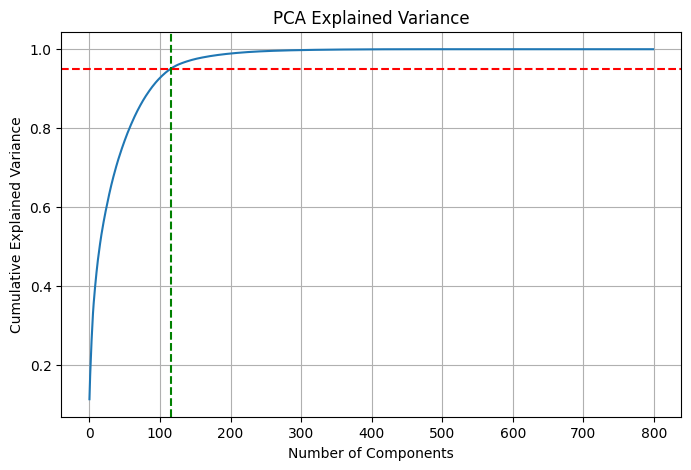

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cumulative_variance)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--'
)

plt.axvline(
    x=n_components,
    color='green',
    linestyle='--'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

### Apply PCA

In [ ]:
pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape :", X_scaled.shape)
print("Reduced Shape  :", X_pca.shape)

Original Shape : (20000, 800)
Reduced Shape  : (20000, 116)


## Classification

### Encode labels

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
print("Classes:", le.classes_)
print("Encoded shape:", y_encoded.shape)

Classes: ['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']
Encoded shape: (20000,)


### Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

X_train Shape: (16000, 116)
X_test Shape : (4000, 116)


### Train Models

In [ ]:
models = {
    "SVM":           SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "KNN":           KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'y_pred': y_pred, 'accuracy': acc, 'model': model}
    print(f"{name} Accuracy: {acc*100:.2f}%")

SVM Accuracy: 99.80%
Random Forest Accuracy: 99.45%
KNN Accuracy: 98.62%


### K-Fold Cross Validation

In [ ]:
cv_results = {}
print('=== 5-Fold Cross-Validation Results ===')
for name, model in models.items():
    scores = cross_val_score(model, X_pca, y_encoded, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:15s} | Mean: {scores.mean()*100:.2f}%  Std: {scores.std()*100:.2f}%")

=== 5-Fold Cross-Validation Results ===
SVM             | Mean: 58.98%  Std: 4.94%
Random Forest   | Mean: 50.44%  Std: 5.73%
KNN             | Mean: 43.93%  Std: 4.58%


### Classification Reports

In [ ]:
for name, res in results.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_test, res['y_pred'], target_names=le.classes_))



--- SVM ---
               precision    recall  f1-score   support

      01_palm       0.99      1.00      0.99       400
         02_l       1.00      0.99      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000


--- Random Forest ---
               precision    recall  f1-score   support

      01_palm       0.99      0.99      0.99       400
         02_l       1.00      0.99      0.99       400
      03_fist       0.99 

### Confusion Matrices¶

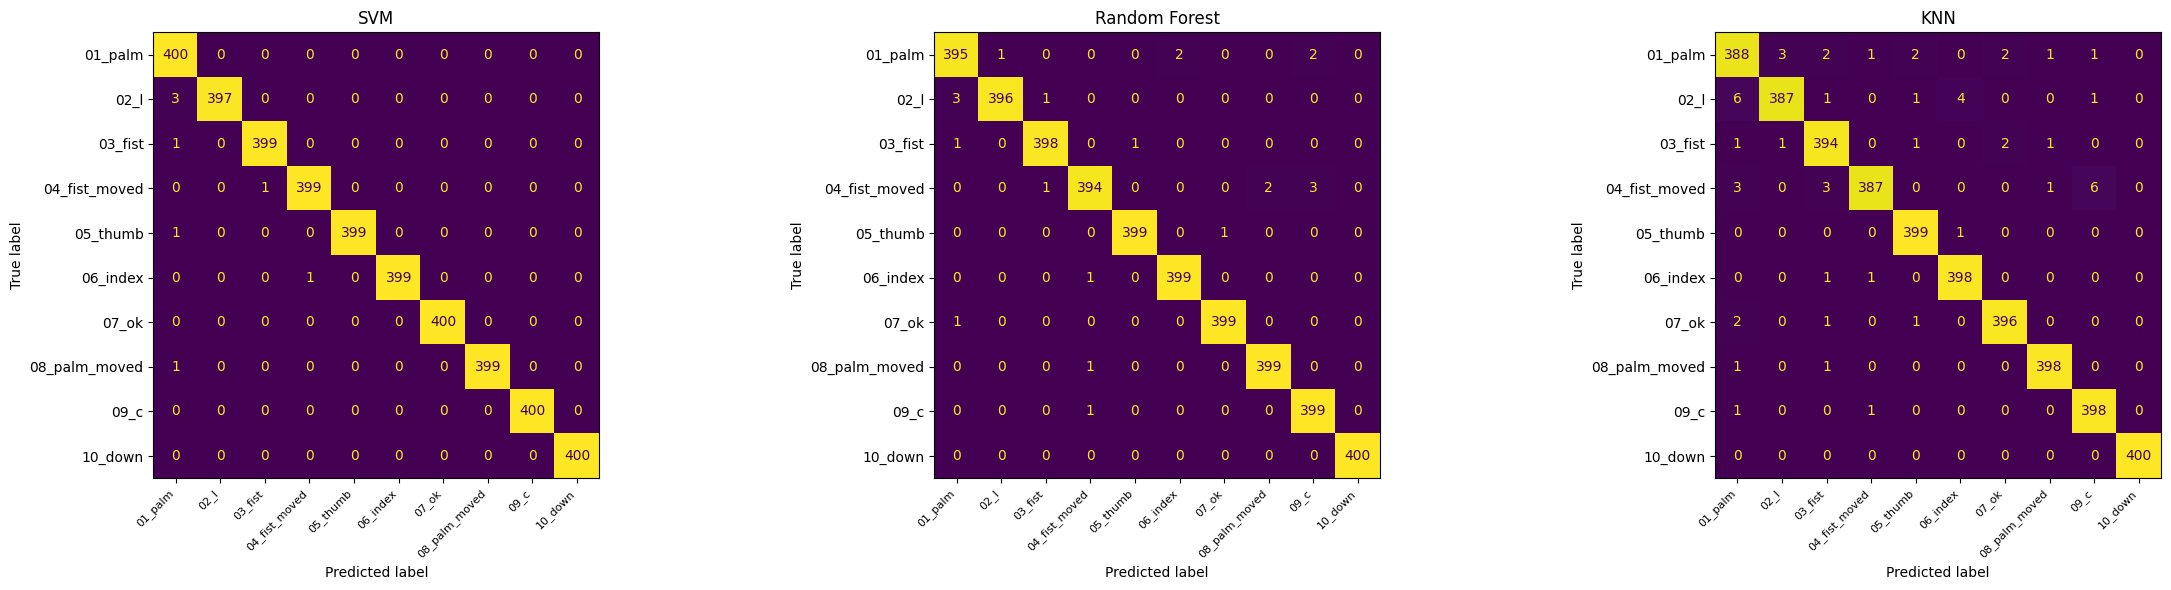

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

### Demo Predictions on test Images

Model: SVM  |  Test Accuracy: 99.80%



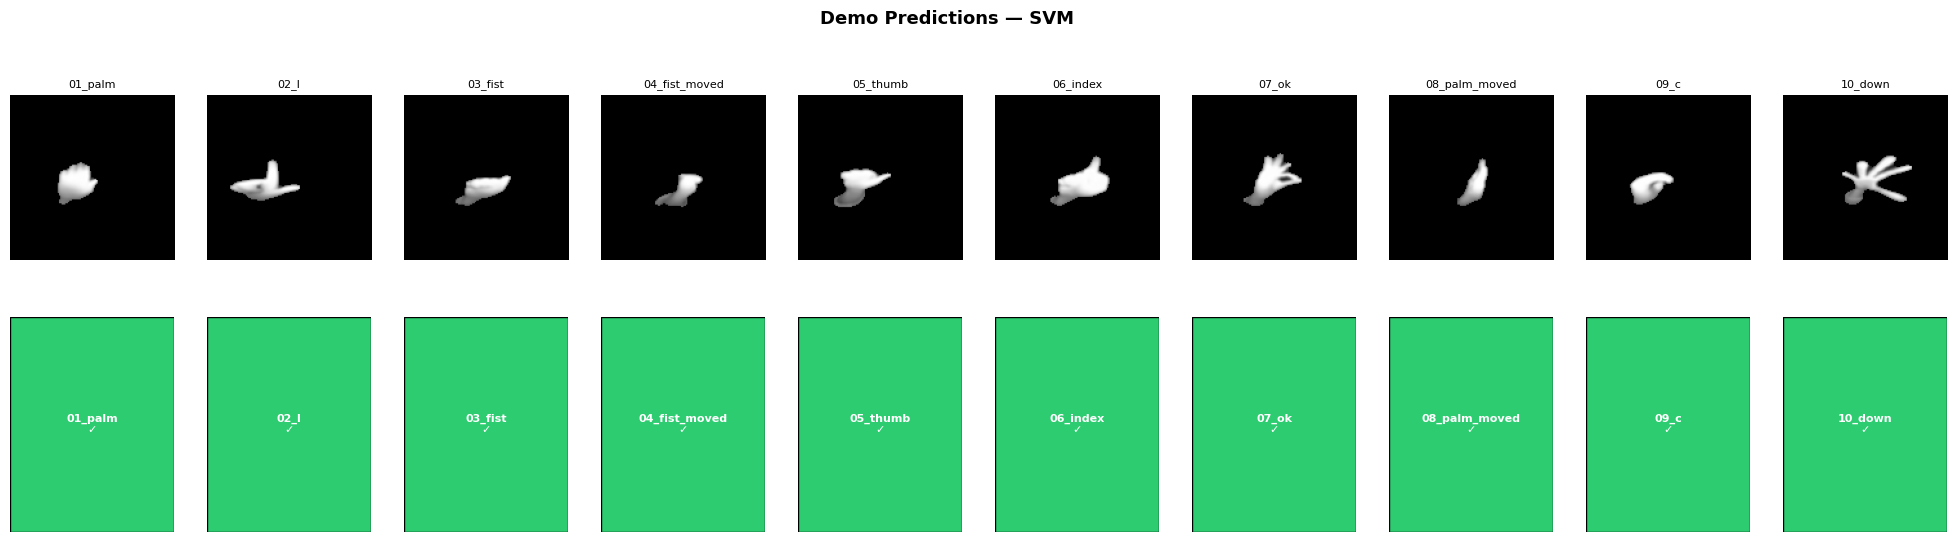

In [ ]:
best_name  = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']
print(f"Model: {best_name}  |  Test Accuracy: {results[best_name]['accuracy']*100:.2f}%\n")

fig, axes = plt.subplots(2, len(le.classes_), figsize=(len(le.classes_) * 2.5, 6))

for col, cls_id in enumerate(range(len(le.classes_))):

    idx = np.where(y_test == cls_id)[0][0]

    true_label = le.classes_[y_test[idx]]
    pred_label = le.classes_[best_model.predict(X_test[[idx]])[0]]
    correct    = true_label == pred_label

    # --- Row 0: segmented image ---
    path = df[df['label'] == true_label]['path'].iloc[0]
    _, _, seg = segment_hand(preprocess_image(path))
    axes[0, col].imshow(seg, cmap='gray')
    axes[0, col].set_title(true_label, fontsize=8)
    axes[0, col].axis('off')

    # --- Row 1: colored box with prediction ---
    color = '#2ecc71' if correct else '#e74c3c'
    axes[1, col].set_xlim(0, 1)
    axes[1, col].set_ylim(0, 1)
    rect = mpatches.FancyBboxPatch((0, 0), 1, 1,
                                    boxstyle="square,pad=0",
                                    facecolor=color, transform=axes[1, col].transData)
    axes[1, col].add_patch(rect)
    axes[1, col].text(0.5, 0.5, f"{pred_label}\n{'✓' if correct else '✗'}",
                      ha='center', va='center', fontsize=8, color='white',
                      fontweight='bold', transform=axes[1, col].transAxes)
    axes[1, col].axis('off')

plt.suptitle(f'Demo Predictions — {best_name}', fontsize=13, fontweight='bold')
plt.subplots_adjust(top=0.88, hspace=0.15)
plt.show()

### Model Comparison & summary

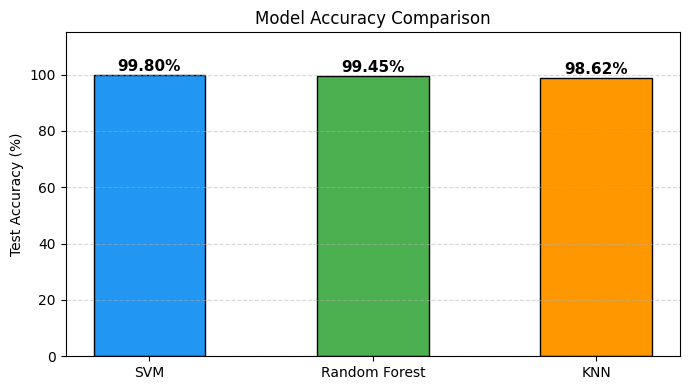

Model             Test Acc    CV Mean     CV Std
------------------------------------------------
SVM                 99.80%     58.98%      4.94%
Random Forest       99.45%     50.44%      5.73%
KNN                 98.62%     43.93%      4.58%

Best model: SVM (99.80%)


In [ ]:
# Accuracy bar chart
names = list(results.keys())
accs  = [results[n]['accuracy'] * 100 for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, accs, color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(0, 115)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# CV summary table
print(f"{'Model':<15} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>10}")
print('-' * 48)
for name in names:
    ta  = results[name]['accuracy'] * 100
    cvm = cv_results[name].mean() * 100
    cvs = cv_results[name].std()  * 100
    print(f"{name:<15} {ta:>9.2f}% {cvm:>9.2f}% {cvs:>9.2f}%")

best = max(results, key=lambda n: results[n]['accuracy'])
print(f"\nBest model: {best} ({results[best]['accuracy']*100:.2f}%)")


## GUI

### Install & import GUI dependencies

In [ ]:
!pip install gradio -q

import gradio as gr
from PIL import Image

In [ ]:
def predict_gesture(img_array):

    # Convert to uint8 first if needed
    if img_array.dtype != np.uint8:
        img_array = (img_array * 255).astype(np.uint8)

    # Step 1: Resize with padding (same as preprocess_image)
    h, w   = img_array.shape
    scale  = min(IMG_SIZE[0] / h, IMG_SIZE[1] / w)
    new_h, new_w = int(h * scale), int(w * scale)
    img    = cv2.resize(img_array, (new_w, new_h), interpolation=cv2.INTER_AREA)

    pad_top    = (IMG_SIZE[0] - new_h) // 2
    pad_bottom = IMG_SIZE[0] - new_h - pad_top
    pad_left   = (IMG_SIZE[1] - new_w) // 2
    pad_right  = IMG_SIZE[1] - new_w - pad_left
    img = cv2.copyMakeBorder(img, pad_top, pad_bottom, pad_left, pad_right,
                              cv2.BORDER_CONSTANT, value=0)

    # Step 2: Denoise (was missing before)
    img = cv2.fastNlMeansDenoising(img, h=10)

    # Step 3: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)

    # Step 4: Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Step 5: Normalize
    preprocessed = img.astype(np.float32) / 255.0

    # Step 6: Segment → HOG
    _, _, segmented = segment_hand(preprocessed)
    seg_small = cv2.resize((segmented * 255).astype(np.uint8), (48, 48))

    feat = hog(seg_small, orientations=8,
               pixels_per_cell=(8, 8),
               cells_per_block=(2, 2),
               block_norm='L2-Hys').reshape(1, -1)

    feat_scaled = scaler.transform(feat)
    feat_pca    = pca.transform(feat_scaled)
    pred_id     = best_model.predict(feat_pca)[0]
    return le.classes_[pred_id]

### Gradio GUI

In [ ]:
def predict_from_upload(image):

    if image is None:
        return "Please upload an image.", None, None

    # Convert RGB → grayscale numpy array (uint8)
    img_gray = np.array(image.convert("L"))

    # ── Apply the FULL preprocess_image pipeline (must match training) ──
    h, w  = img_gray.shape
    scale = min(IMG_SIZE[0] / h, IMG_SIZE[1] / w)
    new_h, new_w = int(h * scale), int(w * scale)
    img = cv2.resize(img_gray, (new_w, new_h), interpolation=cv2.INTER_AREA)

    pad_top    = (IMG_SIZE[0] - new_h) // 2
    pad_bottom = IMG_SIZE[0] - new_h - pad_top
    pad_left   = (IMG_SIZE[1] - new_w) // 2
    pad_right  = IMG_SIZE[1] - new_w - pad_left
    img = cv2.copyMakeBorder(img, pad_top, pad_bottom, pad_left, pad_right,
                             cv2.BORDER_CONSTANT, value=0)

    img = cv2.fastNlMeansDenoising(img, h=10)                    # denoise
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)                                      # CLAHE
    img = cv2.GaussianBlur(img, (3, 3), 0)                       # blur
    preprocessed = img.astype(np.float32) / 255.0                # normalize

    # Segment the hand from background
    _, _, seg = segment_hand(preprocessed)

    # Extract HOG features (same settings as training)
    seg_small = cv2.resize((seg * 255).astype(np.uint8), (48, 48))
    feat = hog(seg_small, orientations=8,
               pixels_per_cell=(8, 8),
               cells_per_block=(2, 2),
               block_norm='L2-Hys').reshape(1, -1)

    # Scale → PCA → Predict
    feat_scaled = scaler.transform(feat)
    feat_pca    = pca.transform(feat_scaled)
    pred_id     = best_model.predict(feat_pca)[0]
    predicted   = le.classes_[pred_id]

    # Clean the class name for better display
    pred_clean = predicted.split("_", 1)[-1].replace("_", " ").title()

    # Convert images back to PIL for Gradio display
    orig_pil = Image.fromarray(img_gray)
    seg_pil  = Image.fromarray((seg * 255).astype(np.uint8))

    # Create output label with prediction result, model name and test accuracy
    label = (
        f"## Predicted: {pred_clean}\n\n"
        f"**Model:** {best_name} | "
        f"**Test Accuracy:** {results[best_name]['accuracy'] * 100:.2f}%"
    )

    # Return: Prediction text / Original image / Segmented image
    return label, orig_pil, seg_pil


# Create Gradio interface
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Hand Gesture Recognizer"
) as demo:

    # Main title shown at top of page
    gr.Markdown("""
    # Hand Gesture Recognizer

    Upload a hand gesture image and the model
    will predict the gesture class.
    """)

    # Create two columns layout
    with gr.Row():
        # Left side → Input section
        with gr.Column(scale=1):
            # Image upload box
            input_img = gr.Image(
                type="pil",
                label="Upload Image"
            )
            # Predict button
            predict_btn = gr.Button(
                "Predict",
                variant="primary",
                size="lg"
            )
        # Right side → Output section
        with gr.Column(scale=2):
            # Text result area
            result_md = gr.Markdown(
                value="Result will appear here..."
            )
            # Show original + segmented images
            with gr.Row():
                # Original uploaded image
                orig_out = gr.Image(
                    label="Original",
                    show_download_button=False
                )
                # Segmented hand image
                seg_out = gr.Image(
                    label="Segmented",
                    show_download_button=False
                )

    # When user clicks Predict button:
    # Run predict_from_upload function
    predict_btn.click(
        fn=predict_from_upload,
        inputs=input_img,
        outputs=[result_md, orig_out, seg_out]
    )

# Launch the app, share=True creates public link
demo.launch(share=True)

/tmp/ipykernel_7465/1102355269.py:65: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://985deb2734526dff4c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
